In [1]:
import pandas as pd
import os

BASE_PATH = os.path.join("..", "..","data", "Dataset_T-ITS.csv")

Importando base "Cyber-Physical Dataset for UAVs Under Normal Operations and Cyber-Attacks — IEEE DataPort"

In [2]:
df_data = pd.read_csv(BASE_PATH, sep=",", low_memory=False)

In [3]:
print(df_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 54783 entries, 0 to 54782
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   timestamp_c             54783 non-null  str  
 1   frame.number            54783 non-null  str  
 2   frame.len               54783 non-null  str  
 3   frame.protocols         54783 non-null  str  
 4   wlan.duration           54783 non-null  str  
 5   wlan.ra                 54783 non-null  str  
 6   wlan.ta                 54783 non-null  str  
 7   wlan.da                 54783 non-null  str  
 8   wlan.sa                 54783 non-null  str  
 9   wlan.bssid              54783 non-null  str  
 10  wlan.frag               54783 non-null  str  
 11  wlan.seq                54783 non-null  str  
 12  llc.type                54783 non-null  str  
 13  ip.hdr_len              54783 non-null  str  
 14  ip.len                  54783 non-null  str  
 15  ip.id                   54783 

In [4]:
print(df_data.columns)

Index(['timestamp_c', 'frame.number', 'frame.len', 'frame.protocols',
       'wlan.duration', 'wlan.ra', 'wlan.ta', 'wlan.da', 'wlan.sa',
       'wlan.bssid', 'wlan.frag', 'wlan.seq', 'llc.type', 'ip.hdr_len',
       'ip.len', 'ip.id', 'ip.flags', 'ip.ttl', 'ip.proto', 'ip.src', 'ip.dst',
       'tcp.srcport', 'tcp.dstport', 'tcp.seq_raw', 'tcp.ack_raw',
       'tcp.hdr_len', 'tcp.flags', 'tcp.window_size', 'tcp.options',
       'udp.srcport', 'udp.dstport', 'udp.length', 'data.data', 'data.len',
       'wlan.fc.type', 'wlan.fc.subtype', 'time_since_last_packet', 'class'],
      dtype='str')


In [5]:
print(df_data["class"].value_counts())

class
Replay        12006
DoS attack    11671
benign         9425
class             2
Name: count, dtype: int64


In [6]:
# Convertendo as colunas de tamanho para numérico
cols_tamanho = ['frame.len', 'ip.len', 'data.len']
for col in cols_tamanho:
    df_data[col] = pd.to_numeric(df_data[col], errors='coerce')

# Removendo possíveis NaNs gerados na conversão
df_clean = df_data.dropna(subset=cols_tamanho + ['class'])

In [7]:
analise_estatistica = df_clean.groupby('class')[cols_tamanho].agg(['mean', 'std', 'max', 'min'])
analise_estatistica

frame.len                             ip.len                    \
                  mean        std    max   min       mean        std    max   
class                                                                         
DoS attack   44.231771  51.334134  334.0  24.0  15.653414  48.794597  302.0   
Replay       49.202899  57.531319  334.0  24.0  20.173080  54.732501  302.0   
benign      127.104509  94.262158  334.0  24.0  92.005942  93.926543  302.0   

                  data.len                         
            min       mean        std    max  min  
class                                              
DoS attack  0.0   9.844829  39.279531  179.0  0.0  
Replay      0.0  13.782442  46.129085  182.0  0.0  
benign      0.0  74.061114  83.864633  181.0  0.0

In [8]:
# Certifique-se de que a coluna de tempo é numérica
df_data['time_since_last_packet'] = pd.to_numeric(df_data['time_since_last_packet'], errors='coerce')

# Mantém df_clean alinhado com df_data após a conversão temporal
cols_tamanho = ['frame.len', 'ip.len', 'data.len']
df_clean = df_data.dropna(subset=cols_tamanho + ['class'])

# Análise estatística do intervalo de tempo
analise_temporal = df_data.groupby('class')['time_since_last_packet'].agg(['mean', 'std', 'min', 'max'])
print(analise_temporal)

                mean       std  min        max
class                                         
DoS attack  0.051417  0.441322  0.0  27.724660
Replay      0.085303  0.399871  0.0  17.089158
benign      0.434762  1.201406  0.0  28.844855
class            NaN       NaN  NaN        NaN


In [9]:
# M1 — *features* estendidas (ver documento de melhorias). A normalização MinMax é aplicada
# **após** o split temporal (célula seguinte), só com estatísticas do treino.
FEATS_V2 = [
    'frame.len',
    'ip.len',
    'time_since_last_packet',
    'wlan.fc.type',
    'wlan.duration',
    'udp.length',
    'data.len',
]

In [10]:
import numpy as np


def preparar_sequencias(data, target, window_size=10):
    if len(data) <= window_size:
        raise ValueError(
            f"Só há {len(data)} linhas após filtros; é preciso mais de {window_size} "
            "para montar janelas. Afrouxe o dropna ou reduza window."
        )
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(np.asarray(data[i : (i + window_size)], dtype=np.float32))
        y.append(int(target[i + window_size]))
    # np.array([]) vira rank 1 (shape (0,)) e quebra o reshape — usar np.stack
    return np.stack(X, axis=0), np.asarray(y, dtype=np.int64)


df_model = df_clean.copy()
# No Dataset T-ITS, `timestamp_c` é tempo relativo numérico (ex.: 28105.9752), não data ISO.
# `pd.to_datetime` gera NaT para quase todas as linhas e esvazia o DataFrame após dropna.
df_model['timestamp_c'] = pd.to_numeric(df_model['timestamp_c'], errors='coerce')
df_model = df_model.dropna(subset=['timestamp_c'])
for col in FEATS_V2:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Exigir só as colunas base sem NaN; o restante imputa (evita esvaziar o CSV com dropna em 7 colunas)
base_cols = ['frame.len', 'ip.len', 'time_since_last_packet']
df_model = df_model.dropna(subset=base_cols + ['class'])
for col in FEATS_V2:
    if col in base_cols:
        continue
    med = df_model[col].median()
    if pd.isna(med):
        med = 0.0
    df_model[col] = df_model[col].fillna(med)

df_model = df_model.sort_values('timestamp_c').reset_index(drop=True)
if not df_model['timestamp_c'].is_monotonic_increasing:
    raise AssertionError('CSV não está ordenado por timestamp_c — verifique os dados.')

target = df_model['class'].map({'benign': 0, 'DoS attack': 1, 'Replay': 2}).values
data = df_model[FEATS_V2].values.astype(np.float32)

window = 10
X, y = preparar_sequencias(data, target, window)
print(f'Formato dos dados para a LSTM: {X.shape}  (janela={window}, features={len(FEATS_V2)})')

Formato dos dados para a LSTM: (33092, 10, 7)  (janela=10, features=7)


In [11]:
from sklearn.preprocessing import MinMaxScaler

# M2 — split temporal **por classe** (80/20 dentro de cada rótulo, ordenado por `timestamp_c`).
# Um corte único nos primeiros 80% das janelas globais pode deixar o teste **sem** uma classe
# (ex.: DoS só no bloco temporal que cai inteiro no treino) — métricas ficam indefinidas.
n_total = len(X)
t_row = df_model['timestamp_c'].to_numpy(dtype=np.float64)
t_label = t_row[window : window + n_total]
idx_all = np.arange(n_total, dtype=np.int64)
train_mask = np.zeros(n_total, dtype=bool)
test_mask = np.zeros(n_total, dtype=bool)
for c in np.unique(y):
    ic = idx_all[y == c]
    if len(ic) == 0:
        continue
    order = np.argsort(t_label[ic])
    idx_sorted = ic[order]
    if len(idx_sorted) < 2:
        train_mask[idx_sorted] = True
        continue
    sp_c = int(0.8 * len(idx_sorted))
    sp_c = max(1, min(sp_c, len(idx_sorted) - 1))
    train_mask[idx_sorted[:sp_c]] = True
    test_mask[idx_sorted[sp_c:]] = True
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Distribuição treino:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Distribuição teste: ', dict(zip(*np.unique(y_test, return_counts=True))))

if X_train.ndim != 3:
    raise ValueError(
        f"X_train deveria ser 3D (N, janela, features); shape={X_train.shape}. "
        "Reexecute a célula que monta X, y a partir de df_model."
    )

scaler = MinMaxScaler()
n, w, f = X_train.shape
X_train = scaler.fit_transform(X_train.reshape(-1, f)).reshape(n, w, f)
X_test = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape[0], w, f)

# Validação durante o treino: últimos 10% do bloco de treino (sem mistura aleatória)
val_split_idx = int(0.9 * len(X_train))
X_tr_fit, X_val_fit = X_train[:val_split_idx], X_train[val_split_idx:]
y_tr_fit, y_val_fit = y_train[:val_split_idx], y_train[val_split_idx:]

Treino: (26472, 10, 7) | Teste: (6620, 10, 7)
Distribuição treino: {np.int64(0): np.int64(7540), np.int64(1): np.int64(9336), np.int64(2): np.int64(9596)}
Distribuição teste:  {np.int64(0): np.int64(1885), np.int64(1): np.int64(2335), np.int64(2): np.int64(2400)}


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    # Nova forma recomendada: Definir a entrada primeiro
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # Camada LSTM: 50 unidades
    LSTM(50, return_sequences=False),
    
    # Dropout para evitar Overfitting
    Dropout(0.2),
    
    # Camada densa final
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,753 (45.91 KB)

 Trainable params: 11,753 (45.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


  1/745 ━━━━━━━━━━━━━━━━━━━━ 16:21 1s/step - accuracy: 0.3125 - loss: 1.1258

 23/745 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3939 - loss: 1.0687  

 48/745 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4574 - loss: 1.0144

 73/745 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4835 - loss: 0.9776

...

722/745 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6582 - loss: 0.6407

745/745 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6573 - loss: 0.6420 - val_accuracy: 0.9566 - val_loss: 0.3226


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 5.


Épocas treinadas: 10


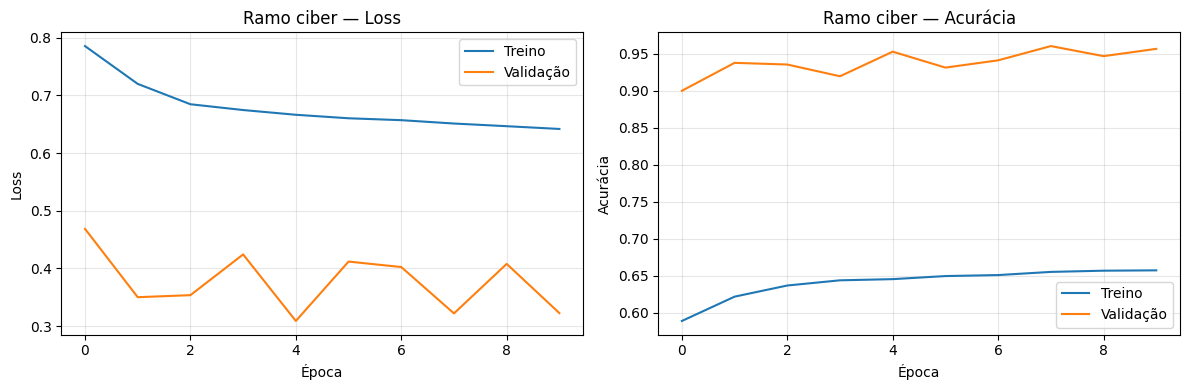

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
checkpoint = ModelCheckpoint(
    'best_model_cyber.keras', monitor='val_loss', save_best_only=True, verbose=0
)

history = model.fit(
    X_tr_fit,
    y_tr_fit,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_fit, y_val_fit),
    callbacks=[early_stop, checkpoint],
    verbose=1,
)
print(f'Épocas treinadas: {len(history.history["loss"])}')

# M3 — curvas de aprendizado
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Ramo ciber — Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Ramo ciber — Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves_ramo_ciber.png', dpi=150)
plt.show()

=== LSTM — Ramo ciber (T-ITS) ===
              precision    recall  f1-score   support

      Benign      0.763     0.975     0.856      1885
  DoS attack      0.593     0.864     0.703      2335
      Replay      0.774     0.261     0.391      2400

    accuracy                          0.677      6620
   macro avg      0.710     0.700     0.650      6620
weighted avg      0.707     0.677     0.633      6620

F1 macro (LSTM): 0.6500


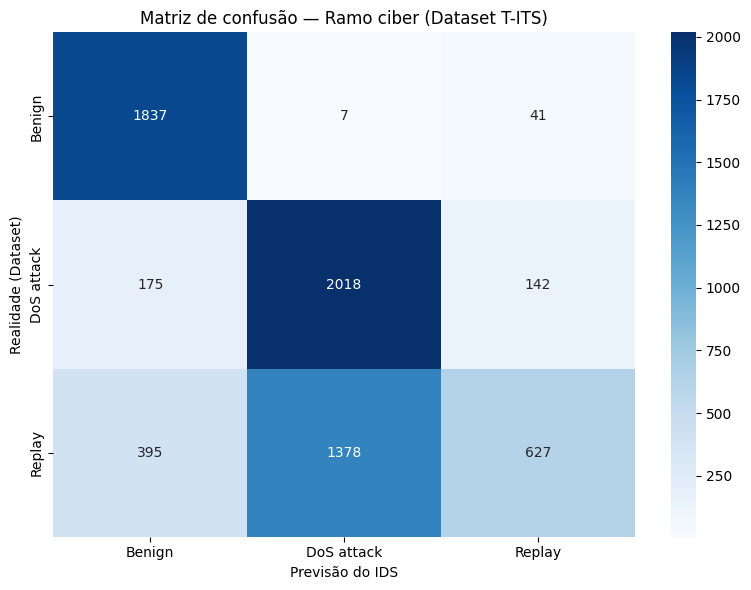

=== Random Forest — Ramo ciber ===
              precision    recall  f1-score   support

      Benign      0.759     0.979     0.855      1885
  DoS attack      0.608     0.574     0.591      2335
      Replay      0.599     0.495     0.542      2400

    accuracy                          0.661      6620
   macro avg      0.655     0.683     0.663      6620
weighted avg      0.648     0.661     0.648      6620

F1 macro (RF): 0.6627


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
names = ['Benign', 'DoS attack', 'Replay']

print('=== LSTM — Ramo ciber (T-ITS) ===')
print(classification_report(y_test, y_pred_classes, target_names=names, digits=3))
print(f"F1 macro (LSTM): {f1_score(y_test, y_pred_classes, average='macro'):.4f}")

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=names,
    yticklabels=names,
)
plt.xlabel('Previsão do IDS')
plt.ylabel('Realidade (Dataset)')
plt.title('Matriz de confusão — Ramo ciber (Dataset T-ITS)')
plt.tight_layout()
plt.savefig('confusion_matrix_cyber.png', dpi=150)
plt.show()

# A2 — baseline Random Forest (janelas achatadas)
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
rf_cyber = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_cyber.fit(X_train_flat, y_train)
y_pred_rf = rf_cyber.predict(X_test_flat)
print('=== Random Forest — Ramo ciber ===')
print(classification_report(y_test, y_pred_rf, target_names=names, digits=3))
print(f"F1 macro (RF): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

In [15]:
# M5 — ablation do tamanho de janela no ramo ciber, usando a MESMA config do
# treino principal (célula M2 + treino com EarlyStopping/ModelCheckpoint), para
# isolar o efeito da janela: split temporal 80/20 **por classe** (não um corte
# único global), MinMaxScaler ajustado só no treino, e até 100 épocas com
# EarlyStopping(patience=5, restore_best_weights=True) — só a janela varia.
# Random Forest é treinado no mesmo split/janela (janelas achatadas), reaproveitando
# Xtr_s/Xte_s já montados para o LSTM — custo extra desprezível (RF treina em segundos).
# (demora vários minutos: até 100 épocas x 5 janelas para o LSTM, com early stopping)
RUN_WINDOW_ABLATION = True

if RUN_WINDOW_ABLATION:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import f1_score
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.models import Sequential

    def split_por_classe(Xw, yw, t_label_full, window_ws, frac_train=0.8):
        """Espelha a célula M2: split temporal 80/20 dentro de cada classe,
        não um corte único global."""
        n_total_w = len(Xw)
        t_label_w = t_label_full[window_ws : window_ws + n_total_w]
        idx_all_w = np.arange(n_total_w, dtype=np.int64)
        train_mask_w = np.zeros(n_total_w, dtype=bool)
        test_mask_w = np.zeros(n_total_w, dtype=bool)
        for c in np.unique(yw):
            ic = idx_all_w[yw == c]
            if len(ic) == 0:
                continue
            order = np.argsort(t_label_w[ic])
            idx_sorted = ic[order]
            if len(idx_sorted) < 2:
                train_mask_w[idx_sorted] = True
                continue
            sp_c = int(frac_train * len(idx_sorted))
            sp_c = max(1, min(sp_c, len(idx_sorted) - 1))
            train_mask_w[idx_sorted[:sp_c]] = True
            test_mask_w[idx_sorted[sp_c:]] = True
        return train_mask_w, test_mask_w

    t_row_full = df_model['timestamp_c'].to_numpy(dtype=np.float64)

    resultados_janela = {}
    resultados_janela_rf = {}
    for ws in [5, 10, 20, 30, 50]:
        Xw, yw = preparar_sequencias(data, target, window_size=ws)

        train_mask_w, test_mask_w = split_por_classe(Xw, yw, t_row_full, ws)
        Xtr, Xte = Xw[train_mask_w], Xw[test_mask_w]
        ytr, yte = yw[train_mask_w], yw[test_mask_w]

        n0, w0, f0 = Xtr.shape
        sc = MinMaxScaler()
        Xtr_s = sc.fit_transform(Xtr.reshape(-1, f0)).reshape(n0, w0, f0)
        Xte_s = sc.transform(Xte.reshape(-1, f0)).reshape(Xte.shape[0], w0, f0)

        # Validação: últimos 10% do bloco de treino (sem mistura aleatória) — igual à M2
        vix = int(0.9 * len(Xtr_s))
        Xa, Xb = Xtr_s[:vix], Xtr_s[vix:]
        ya, yb = ytr[:vix], ytr[vix:]

        m = Sequential(
            [
                Input(shape=(w0, f0)),
                LSTM(50, return_sequences=False),
                Dropout(0.2),
                Dense(3, activation='softmax'),
            ]
        )
        m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        early_stop_ws = EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
        )
        hist = m.fit(
            Xa, ya,
            epochs=100,
            batch_size=32,
            validation_data=(Xb, yb),
            callbacks=[early_stop_ws],
            verbose=0,
        )

        yp = np.argmax(m.predict(Xte_s, verbose=0), axis=1)
        resultados_janela[ws] = f1_score(yte, yp, average='macro')

        # Random Forest — mesmo split/janela, janelas achatadas (mesma normalização MinMax do LSTM)
        rf_ws = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf_ws.fit(Xtr_s.reshape(len(Xtr_s), -1), ytr)
        yp_rf = rf_ws.predict(Xte_s.reshape(len(Xte_s), -1))
        resultados_janela_rf[ws] = f1_score(yte, yp_rf, average='macro')

        print(
            f'window={ws:3d} -> F1 macro LSTM = {resultados_janela[ws]:.4f} '
            f'(épocas treinadas: {len(hist.history["loss"])}) | '
            f'F1 macro RF = {resultados_janela_rf[ws]:.4f} | teste: {len(yte)} janelas'
        )
    print('Melhor janela (LSTM):', max(resultados_janela, key=resultados_janela.get))
    print('Melhor janela (RF):', max(resultados_janela_rf, key=resultados_janela_rf.get))

window=  5 -> F1 macro LSTM = 0.6329 (épocas treinadas: 12) | F1 macro RF = 0.6497 | teste: 6621 janelas
window= 10 -> F1 macro LSTM = 0.6166 (épocas treinadas: 7) | F1 macro RF = 0.6627 | teste: 6620 janelas
window= 20 -> F1 macro LSTM = 0.6482 (épocas treinadas: 18) | F1 macro RF = 0.6664 | teste: 6618 janelas
window= 30 -> F1 macro LSTM = 0.6744 (épocas treinadas: 15) | F1 macro RF = 0.6681 | teste: 6616 janelas
window= 50 -> F1 macro LSTM = 0.6746 (épocas treinadas: 12) | F1 macro RF = 0.6915 | teste: 6612 janelas
Melhor janela (LSTM): 50
Melhor janela (RF): 50


### Inspeção direcionada: **Replay** vs **DoS attack**

O bloco de modelagem acima usa `FEATS_V2` (inclui `wlan.fc.type`, `wlan.duration`, `udp.length`, `data.len`, etc.). Abaixo comparamos **outras** colunas da pilha (**TCP/UDP, WLAN, LLC** e mais campos **IP**), para ver **o que os dois ataques têm em comum** e onde há **diferença** (candidatas a *features* adicionais).

*Nota:* muitas colunas têm **muitos `NaN`** em frames sem essa camada — as taxas de preenchimento aparecem por classe.

Linhas Replay+DoS: 23677 | Colunas candidatas à inspeção: 30


classe,DoS attack,Replay,diff_Replay_menos_DoS
coluna,,,
data.data,100.0,100.0,0.0
data.len,100.0,100.0,0.0
wlan.seq,100.0,100.0,0.0
wlan.sa,100.0,100.0,0.0
wlan.ra,100.0,100.0,0.0
wlan.frag,100.0,100.0,0.0
wlan.fc.type,100.0,100.0,0.0
wlan.fc.subtype,100.0,100.0,0.0
wlan.duration,100.0,100.0,0.0



=== data.data (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=145
data.data
0     10866
16       28
1        26
12       23
29       22 

  DoS attack: n_validos=11671 | nunique=133
data.data
0      10824
65        39
115       38
61        28
45        26 


=== frame.protocols (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=6
frame.protocols
0    10001
3     1046
2      898
1       52
4        7 

  DoS attack: n_validos=11671 | nunique=6
frame.protocols
0    10036
3      847
2      682
1       76
4       28 


=== tcp.options (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=2
tcp.options
0    11188
1      818 

  DoS attack: n_validos=11671 | nunique=2
tcp.options
0    10989
1      682 


=== wlan.bssid (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=1
wlan.bssid
0    12006 

  DoS attack: n_validos=11671 | nunique=1
wlan.bssid
0    11671 


=== wlan.da (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=7
wlan.da
1    6840
0    461

,count,mean,std,median,min,max
class,,,,,,
DoS attack,11671,1.077371,0.302961,1.0,1,3
Replay,12006,1.094286,0.327965,1.0,1,3



=== Estatísticas numéricas Replay vs DoS (colunas com ≥50 valores por classe) ===


,mean_Replay,mean_DoS,std_Replay,std_DoS,median_Replay,median_DoS,mannwhitney_p,sig_5pct
coluna,,,,,,,,
wlan.fc.type,7.687823e-01,3.514695e-01,9.729426e-01,7.612212e-01,0.0,0.0,5.734683e-279,True
wlan.seq,1.272489e+03,1.617667e+03,1.298674e+03,1.249948e+03,771.0,1320.0,8.240472e-158,True
wlan.duration,2.403251e+02,2.736164e+02,1.085572e+02,9.613449e+01,314.0,314.0,9.633540e-158,True
ip.proto,2.035732e+00,1.628052e+00,5.095945e+00,4.601240e+00,0.0,0.0,3.621001e-11,True
ip.id,3.333612e+03,2.952480e+03,1.293157e+04,1.188945e+04,0.0,0.0,4.221906e-11,True
ip.ttl,3.261169e+01,2.644546e+01,7.801810e+01,7.120159e+01,0.0,0.0,5.466972e-11,True
data.len,1.378244e+01,9.844829e+00,4.612909e+01,3.927953e+01,0.0,0.0,5.606586e-11,True
ip.hdr_len,3.276695e+00,2.671579e+00,7.402819e+00,6.804279e+00,0.0,0.0,6.246351e-11,True
udp.length,1.471614e+01,1.111190e+01,4.873219e+01,4.324212e+01,0.0,0.0,2.747797e-09,True


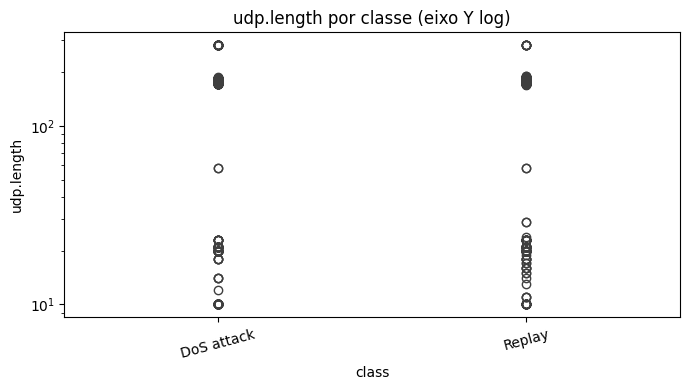

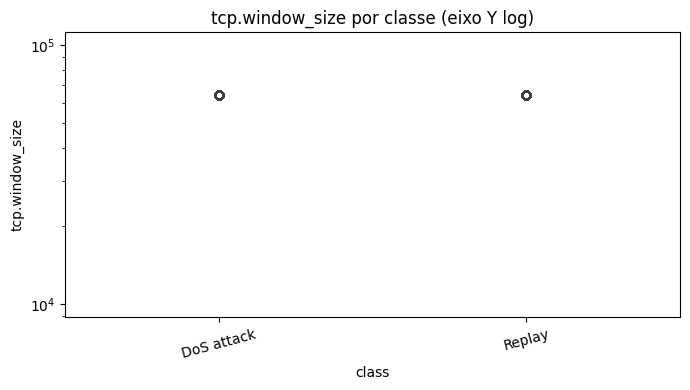

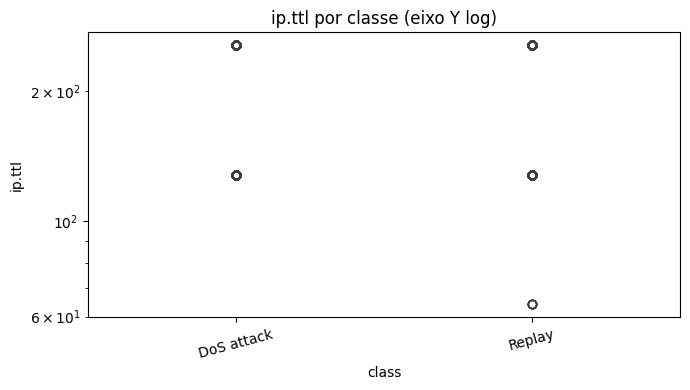

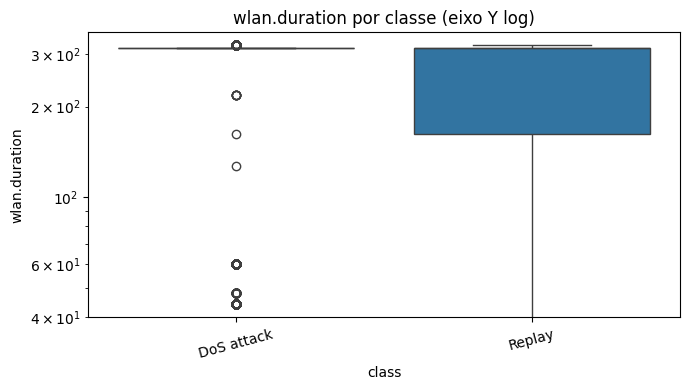

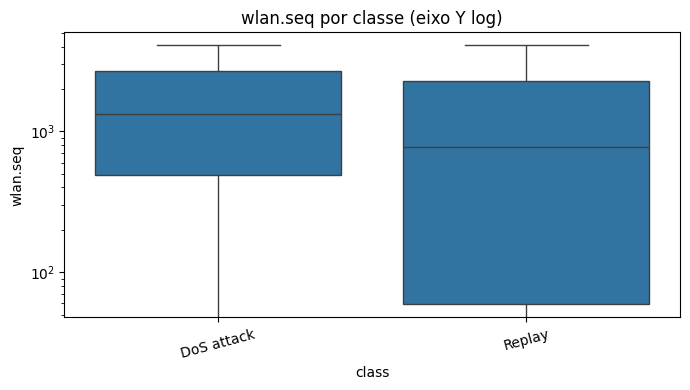

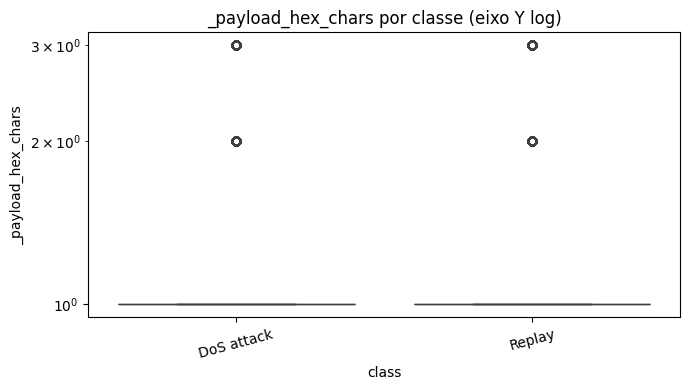

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

FEATS_MODELO = {"frame.len", "ip.len", "time_since_last_packet"}
EXTRAS_IP = {"ip.ttl", "ip.proto", "ip.flags", "ip.id", "ip.hdr_len", "frame.protocols"}
PREFIXOS = ("tcp.", "udp.", "wlan.", "data.", "llc.")

def colunas_inspecao(df):
    out = []
    for c in df.columns:
        if c in ("class", "timestamp_c") or c in FEATS_MODELO:
            continue
        if c.startswith(PREFIXOS) or c in EXTRAS_IP:
            out.append(c)
    return out

COLS_INSP = colunas_inspecao(df_clean)
rd = df_clean[df_clean["class"].isin(["Replay", "DoS attack"])].copy()
print(f"Linhas Replay+DoS: {len(rd)} | Colunas candidatas à inspeção: {len(COLS_INSP)}")

# --- 1) Taxa de não-nulo por classe (qualidade / cobertura) ---
linhas = []
for col in COLS_INSP:
    for lab in ("Replay", "DoS attack"):
        m = rd.loc[rd["class"] == lab, col].notna().mean()
        linhas.append({"coluna": col, "classe": lab, "pct_nao_nulo": round(100 * m, 2)})
cobertura = pd.DataFrame(linhas).pivot(index="coluna", columns="classe", values="pct_nao_nulo")
cobertura["diff_Replay_menos_DoS"] = cobertura["Replay"] - cobertura["DoS attack"]
cobertura = cobertura.assign(_abs_diff=cobertura["diff_Replay_menos_DoS"].abs()).sort_values("_abs_diff", ascending=False).drop(columns="_abs_diff")
display(cobertura)

# --- 2) Colunas tratadas como string (endereços, payload bruto, protocolos) ---
STRING_LIKE = {
    "wlan.ra", "wlan.ta", "wlan.da", "wlan.sa", "wlan.bssid",
    "ip.src", "ip.dst", "data.data", "tcp.options", "frame.protocols",
}

def resumo_categorico(col, top_n=5):
    print(f"\n=== {col} (top {top_n} por classe) ===")
    for lab in ("Replay", "DoS attack"):
        sub = rd.loc[rd["class"] == lab, col].dropna()
        vc = sub.astype(str).value_counts().head(top_n)
        print(f"  {lab}: n_validos={len(sub)} | nunique={sub.nunique()}")
        print(vc.to_string(), "\n")

for c in sorted(STRING_LIKE & set(COLS_INSP)):
    if c in rd.columns:
        resumo_categorico(c, top_n=5)

# Tamanho do hex em data.data (proxy de payload sem decodificar MAVLink)
if "data.data" in rd.columns:
    rd["_payload_hex_chars"] = rd["data.data"].apply(lambda x: len(x) if isinstance(x, str) else np.nan)
    print("\n=== _payload_hex_chars (Replay vs DoS) ===")
    display(
        rd.groupby("class")["_payload_hex_chars"].agg(["count", "mean", "std", "median", "min", "max"])
    )

# --- 3) Colunas numéricas (coerção) ---
num_candidates = [c for c in COLS_INSP if c not in STRING_LIKE]
for c in num_candidates:
    rd[c] = pd.to_numeric(rd[c], errors="coerce")

stats_rows = []
pvalue_rows = []
for col in num_candidates:
    a = rd.loc[rd["class"] == "Replay", col].dropna()
    b = rd.loc[rd["class"] == "DoS attack", col].dropna()
    if len(a) < 50 or len(b) < 50:
        continue
    stats_rows.append({
        "coluna": col,
        "mean_Replay": a.mean(),
        "mean_DoS": b.mean(),
        "std_Replay": a.std(),
        "std_DoS": b.std(),
        "median_Replay": a.median(),
        "median_DoS": b.median(),
    })
    # Teste não-paramétrico (distribuições não normais, caudas pesadas)
    try:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        pvalue_rows.append({"coluna": col, "mannwhitney_p": p})
    except ValueError:
        pass

tab_stats = pd.DataFrame(stats_rows).set_index("coluna")
tab_p = pd.DataFrame(pvalue_rows).set_index("coluna")
if len(tab_p):
    tab_stats = tab_stats.join(tab_p)
    tab_stats["sig_5pct"] = tab_stats["mannwhitney_p"] < 0.05
print("\n=== Estatísticas numéricas Replay vs DoS (colunas com ≥50 valores por classe) ===")
display(tab_stats.sort_values("mannwhitney_p") if "mannwhitney_p" in tab_stats.columns else tab_stats)

# --- 4) Boxplots (escala log) para colunas com boa cobertura e diferença visual ---
plot_cols = [c for c in ["udp.length", "tcp.window_size", "ip.ttl", "wlan.duration", "wlan.seq", "_payload_hex_chars"] if c in rd.columns]
plot_cols = [c for c in plot_cols if rd[c].notna().sum() > 200]
for col in plot_cols:
    sub = rd[["class", col]].dropna()
    if sub["class"].nunique() < 2:
        continue
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=sub, x="class", y=col)
    plt.yscale("log")
    plt.title(f"{col} por classe (eixo Y log)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()